In [1]:
import pathlib
import cv2
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import os

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from keras import models, layers

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile

from tensorflow.keras import optimizers

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

c:\Users\Acer\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
data_dir = "./dog-breed-120/Dogs class"
type(data_dir)

str

In [3]:
data_dir = pathlib.Path(data_dir)
type(data_dir)

pathlib.WindowsPath

In [4]:
data_dir.glob("*")

<generator object Path.glob at 0x000001E5AF85BEF0>

In [5]:
list(data_dir.glob("*"))

[WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua'),
 WindowsPath('dog-breed-120/Dogs class/n02085782-Japanese_spaniel'),
 WindowsPath('dog-breed-120/Dogs class/n02085936-Maltese_dog'),
 WindowsPath('dog-breed-120/Dogs class/n02086079-Pekinese'),
 WindowsPath('dog-breed-120/Dogs class/n02086240-Shih-Tzu'),
 WindowsPath('dog-breed-120/Dogs class/n02086646-Blenheim_spaniel'),
 WindowsPath('dog-breed-120/Dogs class/n02086910-papillon'),
 WindowsPath('dog-breed-120/Dogs class/n02087046-toy_terrier'),
 WindowsPath('dog-breed-120/Dogs class/n02087394-Rhodesian_ridgeback'),
 WindowsPath('dog-breed-120/Dogs class/n02088094-Afghan_hound'),
 WindowsPath('dog-breed-120/Dogs class/n02088238-basset'),
 WindowsPath('dog-breed-120/Dogs class/n02088364-beagle'),
 WindowsPath('dog-breed-120/Dogs class/n02088466-bloodhound'),
 WindowsPath('dog-breed-120/Dogs class/n02088632-bluetick'),
 WindowsPath('dog-breed-120/Dogs class/n02089078-black-and-tan_coonhound'),
 WindowsPath('dog-breed-120/Dogs c

In [6]:
list(data_dir.glob("n02099712-Labrador_retriever/*"))

[WindowsPath('dog-breed-120/Dogs class/n02099712-Labrador_retriever/n02099712_1150.jpg'),
 WindowsPath('dog-breed-120/Dogs class/n02099712-Labrador_retriever/n02099712_1200.jpg'),
 WindowsPath('dog-breed-120/Dogs class/n02099712-Labrador_retriever/n02099712_1229.jpg'),
 WindowsPath('dog-breed-120/Dogs class/n02099712-Labrador_retriever/n02099712_1254.jpg'),
 WindowsPath('dog-breed-120/Dogs class/n02099712-Labrador_retriever/n02099712_129.jpg'),
 WindowsPath('dog-breed-120/Dogs class/n02099712-Labrador_retriever/n02099712_1383.jpg'),
 WindowsPath('dog-breed-120/Dogs class/n02099712-Labrador_retriever/n02099712_1414.jpg'),
 WindowsPath('dog-breed-120/Dogs class/n02099712-Labrador_retriever/n02099712_1436.jpg'),
 WindowsPath('dog-breed-120/Dogs class/n02099712-Labrador_retriever/n02099712_1660.jpg'),
 WindowsPath('dog-breed-120/Dogs class/n02099712-Labrador_retriever/n02099712_1828.jpg'),
 WindowsPath('dog-breed-120/Dogs class/n02099712-Labrador_retriever/n02099712_1866.jpg'),
 WindowsPat

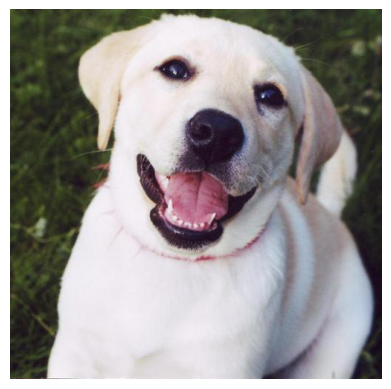

In [9]:
img = cv2.imread(str(list(data_dir.glob("n02099712-Labrador_retriever/*"))[34]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

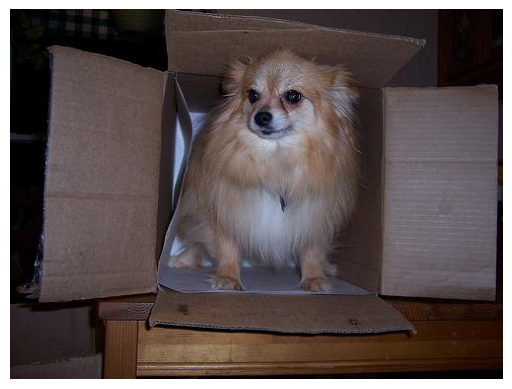

In [11]:
img = cv2.imread(str(list(data_dir.glob("n02112018-Pomeranian/*"))[34]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [12]:
for breed in data_dir.glob("*"):
    print(breed.name, len(list(breed.glob("*"))))

n02085620-Chihuahua 152
n02085782-Japanese_spaniel 185
n02085936-Maltese_dog 252
n02086079-Pekinese 149
n02086240-Shih-Tzu 214
n02086646-Blenheim_spaniel 188
n02086910-papillon 196
n02087046-toy_terrier 172
n02087394-Rhodesian_ridgeback 172
n02088094-Afghan_hound 239
n02088238-basset 175
n02088364-beagle 195
n02088466-bloodhound 187
n02088632-bluetick 171
n02089078-black-and-tan_coonhound 159
n02089867-Walker_hound 153
n02089973-English_foxhound 157
n02090379-redbone 148
n02090622-borzoi 151
n02090721-Irish_wolfhound 218
n02091032-Italian_greyhound 182
n02091134-whippet 187
n02091244-Ibizan_hound 188
n02091467-Norwegian_elkhound 196
n02091635-otterhound 151
n02091831-Saluki 200
n02092002-Scottish_deerhound 232
n02092339-Weimaraner 160
n02093256-Staffordshire_bullterrier 155
n02093428-American_Staffordshire_terrier 164
n02093647-Bedlington_terrier 182
n02093754-Border_terrier 172
n02093859-Kerry_blue_terrier 179
n02093991-Irish_terrier 169
n02094114-Norfolk_terrier 172
n02094258-Norwich

In [13]:
print("Total classes:", len(list(data_dir.glob("*"))))
print("Total images:", len(list(data_dir.glob("*/*"))))

Total classes: 120
Total images: 20580


In [14]:
images_dict = {}

for breed_folder in data_dir.glob("*"):
    images_dict[breed_folder.name] = list(breed_folder.glob("*"))

In [15]:
print(images_dict)

{'n02085620-Chihuahua': [WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_10074.jpg'), WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_10131.jpg'), WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_10621.jpg'), WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_1073.jpg'), WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_10976.jpg'), WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_11140.jpg'), WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_11238.jpg'), WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_11258.jpg'), WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_11337.jpg'), WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_11477.jpg'), WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_1152.jpg'), WindowsPath('dog-breed-120/Dogs class/n02085620-Chihuahua/n02085620_11696.jpg'), Windo

In [16]:
labels_dict = {}

for i, breed_folder in enumerate(sorted(data_dir.glob("*"))):
    labels_dict[breed_folder.name] = i

In [17]:
print(labels_dict)

{'n02085620-Chihuahua': 0, 'n02085782-Japanese_spaniel': 1, 'n02085936-Maltese_dog': 2, 'n02086079-Pekinese': 3, 'n02086240-Shih-Tzu': 4, 'n02086646-Blenheim_spaniel': 5, 'n02086910-papillon': 6, 'n02087046-toy_terrier': 7, 'n02087394-Rhodesian_ridgeback': 8, 'n02088094-Afghan_hound': 9, 'n02088238-basset': 10, 'n02088364-beagle': 11, 'n02088466-bloodhound': 12, 'n02088632-bluetick': 13, 'n02089078-black-and-tan_coonhound': 14, 'n02089867-Walker_hound': 15, 'n02089973-English_foxhound': 16, 'n02090379-redbone': 17, 'n02090622-borzoi': 18, 'n02090721-Irish_wolfhound': 19, 'n02091032-Italian_greyhound': 20, 'n02091134-whippet': 21, 'n02091244-Ibizan_hound': 22, 'n02091467-Norwegian_elkhound': 23, 'n02091635-otterhound': 24, 'n02091831-Saluki': 25, 'n02092002-Scottish_deerhound': 26, 'n02092339-Weimaraner': 27, 'n02093256-Staffordshire_bullterrier': 28, 'n02093428-American_Staffordshire_terrier': 29, 'n02093647-Bedlington_terrier': 30, 'n02093754-Border_terrier': 31, 'n02093859-Kerry_blue

In [18]:
X, y = [], []

for breed, images in images_dict.items():
    for image in images:
        X.append(str(image))        # store image path
        y.append(labels_dict[breed])

In [19]:
X = np.array(X)
y = np.array(y)

In [20]:
X.shape

(20580,)

In [21]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.1765,
    stratify=y_train,
    random_state=42
)

In [22]:
print((np.bincount(y_train) == 0).sum())
print((np.bincount(y_val) == 0).sum())
print((np.bincount(y_test) == 0).sum())

0
0
0


every breed appears in every split

In [23]:
train_df = pd.DataFrame({
    "path": x_train_final,
    "label": y_train_final
})

val_df = pd.DataFrame({
    "path": x_val,
    "label": y_val
})

test_df = pd.DataFrame({
    "path": x_test,
    "label": y_test
})

In [24]:
train_df["label"] = train_df["label"].astype(str)
val_df["label"] = val_df["label"].astype(str)
test_df["label"] = test_df["label"].astype(str)

In [25]:
print(train_df.head())
print(train_df.shape)

                                                path label
0  dog-breed-120\Dogs class\n02111277-Newfoundlan...   104
1  dog-breed-120\Dogs class\n02088094-Afghan_houn...     9
2  dog-breed-120\Dogs class\n02095889-Sealyham_te...    39
3  dog-breed-120\Dogs class\n02096437-Dandie_Dinm...    43
4  dog-breed-120\Dogs class\n02110063-malamute\n0...    98
(14405, 2)


# B.NASNetMobile

In [26]:
from tensorflow.keras.applications.nasnet import preprocess_input

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.8,1.2],
    horizontal_flip=True,
    fill_mode="nearest"
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [27]:
train_generator = train_gen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="label",
    target_size=(224,224),
    class_mode="sparse",
    batch_size=32,
    shuffle=True
)

val_generator = val_gen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="label",
    target_size=(224,224),
    class_mode="sparse",
    batch_size=32,
    shuffle=False
)

Found 14405 validated image filenames belonging to 120 classes.
Found 3088 validated image filenames belonging to 120 classes.


In [28]:
checkpointer = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Colab Notebooks/dog_breed_nasnet_mobile_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.1,
    min_lr=1e-6,
    verbose=1
)

In [29]:
base_model = NASNetMobile(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [30]:
nasnet_model = models.Sequential()

nasnet_model.add(base_model)
nasnet_model.add(layers.GlobalAveragePooling2D())

nasnet_model.add(layers.Dense(256, activation='relu'))
nasnet_model.add(layers.Dropout(0.5))

nasnet_model.add(layers.Dense(120, activation='softmax'))

In [31]:
nasnet_model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
history_nasnet = nasnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=40,
    callbacks=[checkpointer, early_stop, lr_reduce],
    verbose=1
)

Epoch 1/40
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0275 - loss: 4.7756
Epoch 1: val_loss improved from None to 4.02167, saving model to /content/drive/MyDrive/Colab Notebooks/dog_breed_nasnet_mobile_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/dog_breed_nasnet_mobile_best_model.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - accuracy: 0.0555 - loss: 4.5743 - val_accuracy: 0.3468 - val_loss: 4.0217 - learning_rate: 3.0000e-05
Epoch 2/40
451/451 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.1960 - loss: 3.9768
Epoch 2: val_loss improved from 4.02167 to 2.98612, saving model to /content/drive/MyDrive/Colab Notebooks/dog_breed_nasnet_mobile_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/dog_breed_nasnet_mobile_best_model.keras
451/451 ━━━━━━━━━━━━━━━━━━━━ 339s 750ms/step - accuracy: 0.2544 - loss: 3.7640 - val_accuracy: 0.6528 - val_loss: 2.9861 - learning_rate: 3.0000e-05
Epoch 3/4

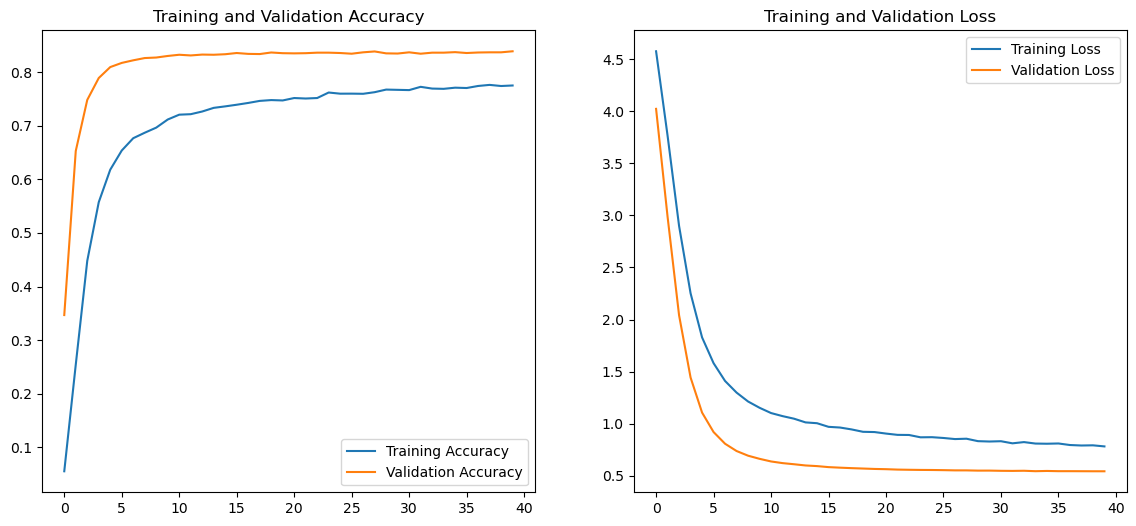

In [33]:
 # Plot training metrics
acc = history_nasnet.history['accuracy']
val_acc = history_nasnet.history['val_accuracy']
loss = history_nasnet.history['loss']
val_loss = history_nasnet.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [34]:
test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_gen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="label",
    target_size=(224,224),
    class_mode="sparse",
    batch_size=32,
    shuffle=False
)

Found 3087 validated image filenames belonging to 120 classes.


In [35]:
nasnet_model.evaluate(test_generator)

97/97 ━━━━━━━━━━━━━━━━━━━━ 79s 822ms/step - accuracy: 0.8452 - loss: 0.5153


[0.5153292417526245, 0.8451570868492126]

### Final Insights

- Transfer learning using **NASNet-A Mobile** was applied for classifying **120 dog breeds**.
- The pretrained model helped extract strong visual features from the dataset.
- The model achieved **~84% test accuracy**, demonstrating effective performance for a large multi-class classification task.
- Some misclassifications occur between **visually similar dog breeds**.
- Performance could be further improved through **data cleaning, augmentation, and deeper fine-tuning**.